## Langgraph basics

In [2]:
from typing_extensions import TypedDict

In [3]:
class State(TypedDict):
    graph_state:str
    # messages: list[dict[str, str]]
    

In [10]:
def first_node(state):
    print("My First Node is called")
    return{"graph_state":state['graph_state']+" I am playing"}

def second_node(state):
    print("My Second Node is called")
    return{"graph_state":state['graph_state']+" Cricket"}

def third_node(state):
    print("My Third Node is called")
    return{"graph_state":state['graph_state']+" Hockey"}

In [5]:
from typing import Literal
import random
def decide_play(state)->Literal["second_node","third_node"]:
    graph_state=state['graph_state']
    
    if random.random()<0.5:
        return "second_node"
    
    return "third_node"

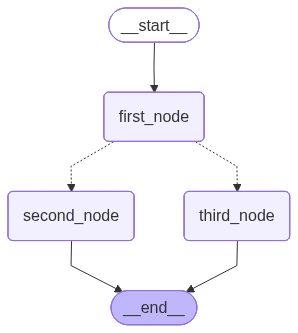

In [13]:
## construct the graph
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END

builder=StateGraph(State)
builder.add_node("first_node",first_node)
builder.add_node("second_node",second_node)
builder.add_node("third_node",third_node)

#logic
builder.add_edge(START,"first_node")
builder.add_conditional_edges("first_node",decide_play)
builder.add_edge("second_node",END)
builder.add_edge("third_node",END)


#Add
graph=builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [14]:
graph.invoke({"graph_state":"Hi, my name is prem,"})

My First Node is called
My Second Node is called


{'graph_state': 'Hi, my name is prem, I am playing Cricket'}